Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

# Path to PE result file

In [2]:
# result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5" #"/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
# injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"#"/Users/arif/Desktop/injection.dat"
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

# Postprocess the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.postprocess import PostProcessForBilby

/Users/arif/gw_eccentricity/gw_eccentricity/load_data.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [4]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [5]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

## Instantiate PostProcessForBilby class

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [7]:
egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_extra_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file)

11:44 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


## Looking at the original posteriors

In [8]:
egwBilby.get_posterior()

,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,...,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,623.536988,35.393036- 1.832653j,36.320440,832.897895,40.886870+ 0.337570j,41.362264,2.022867,79.990989,12.783959+ 0.292588j,13.283787,...,0,0,0.840667,0.241917,0.254826,0.0,0.0,117.996238,87.927810,TEOBResumSDALI
1,623.737121,35.413042- 0.219257j,36.072400,834.313813,40.934172+ 0.893366j,40.930566,2.020499,78.126882,12.680335- 1.206002j,12.763677,...,0,0,0.884071,0.247294,0.799544,0.0,0.0,117.215195,91.807840,TEOBResumSDALI
2,625.263228,35.442456- 1.632387j,35.903969,829.859150,40.812956- 0.412181j,40.807886,2.023034,82.320345,12.970347+ 0.254119j,13.072128,...,0,0,0.756452,0.239020,0.189148,0.0,0.0,116.939708,87.103236,TEOBResumSDALI
3,623.660924,35.395494- 2.728341j,34.966475,833.187739,40.892780+ 2.002818j,40.065281,2.020089,81.065828,12.864432+ 0.454741j,12.946800,...,0,0,0.868357,0.247583,0.161180,0.0,0.0,117.422422,86.382175,TEOBResumSDALI
4,627.470438,35.506280+ 0.409910j,35.208147,830.505277,40.830341- 0.528652j,39.797103,2.020817,79.868891,12.782441+ 0.623043j,12.668456,...,0,0,0.812520,0.239390,0.230434,0.0,0.0,115.367024,86.073716,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12723,626.550917,35.499546+ 0.073499j,36.098698,845.009001,41.201355+ 0.036744j,40.760186,2.020851,82.309320,13.023293- 0.098106j,13.410467,...,0,0,0.885188,0.249987,0.951851,0.0,0.0,118.877416,95.101984,TEOBResumSDALI
12724,626.300630,35.496080- 0.830289j,35.969990,844.760389,41.198333+ 0.404540j,40.711227,2.020917,82.643707,13.059309- 0.070462j,13.374895,...,0,0,0.881033,0.249998,1.021669,0.0,0.0,118.442282,95.681426,TEOBResumSDALI
12725,626.957177,35.513985- 0.266306j,37.514769,844.633748,41.194731+ 0.495985j,42.412076,2.020852,82.200797,13.022836- 0.172487j,13.950999,...,0,0,0.888504,0.249980,1.004888,0.0,0.0,118.374764,96.129032,TEOBResumSDALI
12726,627.806113,35.532200+ 0.171292j,37.527899,844.150416,41.177941+ 1.132581j,42.491474,2.021137,82.267627,13.011608+ 0.770148j,14.006202,...,0,0,0.890064,0.249990,0.893409,0.0,0.0,118.771925,94.895787,TEOBResumSDALI


We can also load the injection in case we are doing an injection using model waveform.

In [9]:
injection = egwBilby.get_injection()

In [10]:
data_dict = egwBilby.get_injection_data_dict()

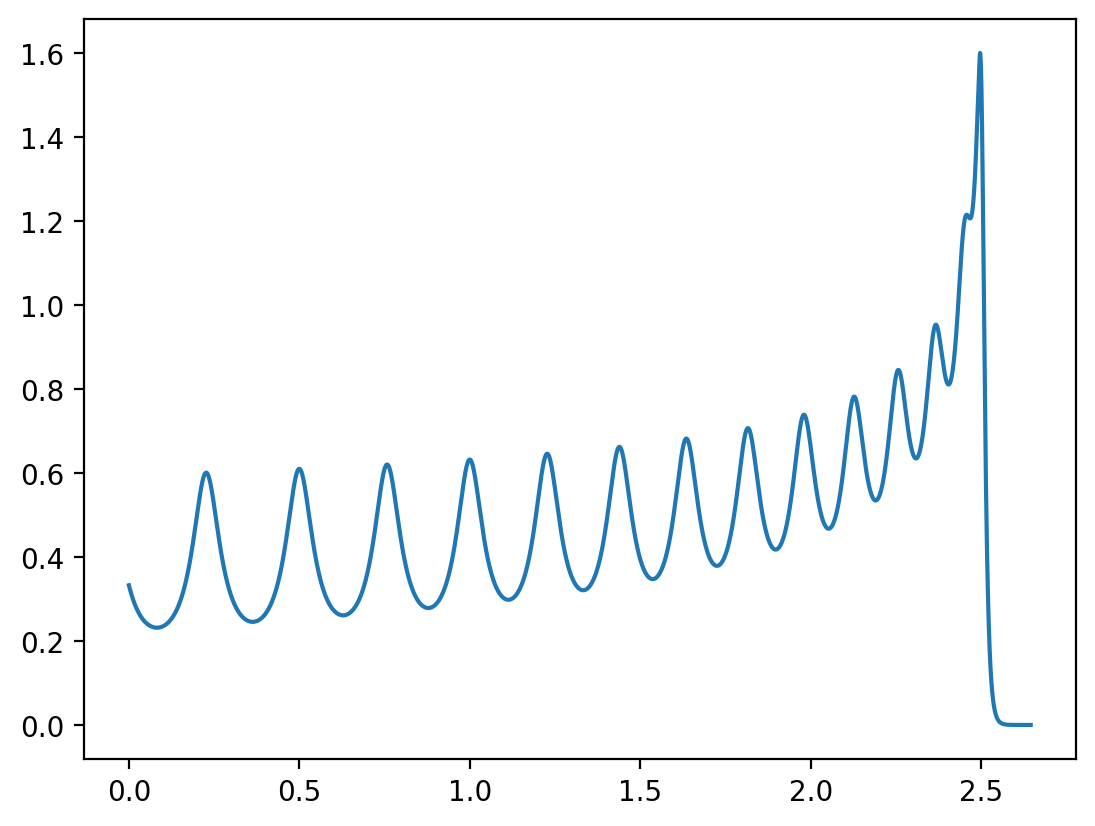

In [11]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

Finally plot the model posterior

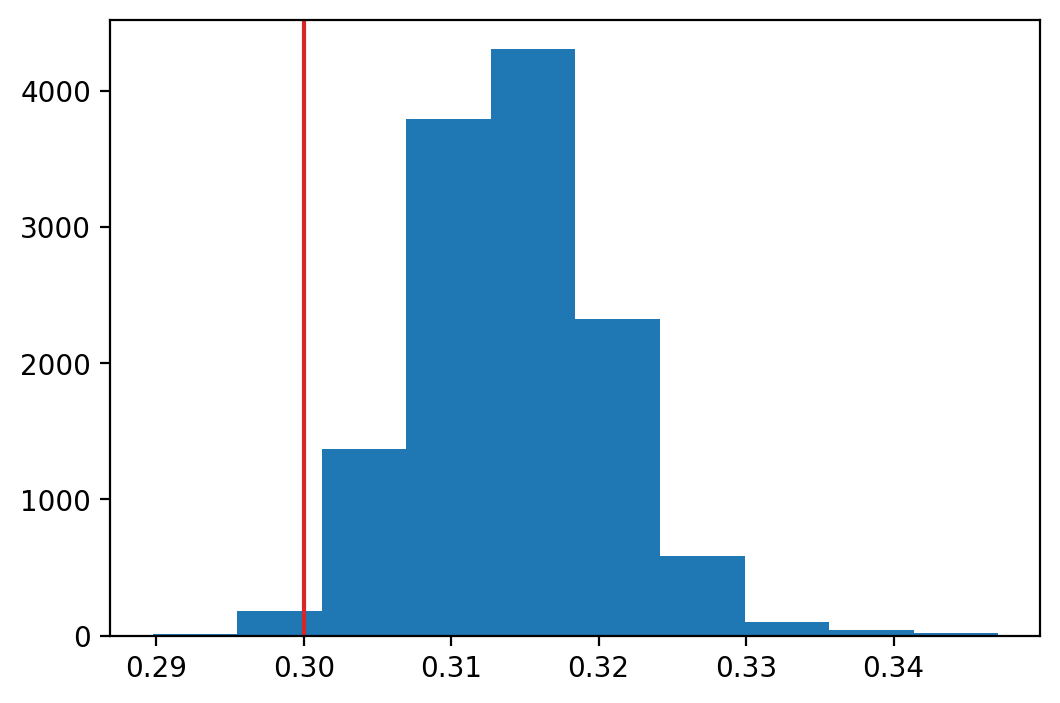

In [12]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

## Getting the allowed range of reference frequencies to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [13]:
import random

In [14]:
# we can use a subset of the samples to save time
samples = random.sample(range(0, len(egwBilby.posterior)), k=100)

In [15]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    # "omega_gw_extrema_interpolation_method": "spline"
}}
n_jobs = 6

In [16]:
fref_bounds_result = egwBilby.get_fref_bounds(
    samples=samples,
    method=method,
    n_jobs=n_jobs,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)
print("Allowed range of reference frequencies are: ", fref_bounds_result.get_minmax_fref())

Getting fref bounds: 0it [00:00, ?it/s]/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Us

Allowed range of reference frequencies are:  (np.float64(8.61439748899305), np.float64(29.820575926325276))


The range of allowed reference frequencies comes from the samples where eccentricity measurement is successfull. We can get a summary of how many samples were successfully processed.

In [17]:
fref_bounds_result.get_summary()["success_percentage"]

100.0

We can also view the full result as a DataFrame

In [18]:
fref_bounds_result.to_dataframe()

,sample_index,status,fref_min,fref_max,error_message
0,4706,success,8.374338,31.463182,None
1,12432,success,8.513867,30.707177,None
2,5244,success,8.389599,31.391438,None
3,3915,success,8.451681,31.035998,None
4,258,success,8.475260,30.882304,None
...,...,...,...,...,...
95,11816,success,8.498361,30.682669,None
96,8912,success,8.551700,30.277290,None
97,2864,success,8.500558,30.777105,None
98,11926,success,8.493333,30.860776,None


## Postprocessing

We can postprocess a subset of the smaples or all the samples using the following method

In [19]:
import time

In [27]:
fref = 10
t_start = time.perf_counter()
samples = random.sample(range(0, len(egwBilby.posterior)), k=1000)
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples: 96it [00:03, 19.62it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through apocenters. 
  debug_message(
Postprocessing samples: 564it [00:33, 15.94it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through pericenters. 
  debug_message(
Postprocessing samples: 708it [00:42, 16.05it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1757: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through apocenters. 
  debug_message(
Postprocessing samples: 1000it [01:01, 16.38it/s]
/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:2767: UserWarning: egw(t) is nonmonotonic at 2.357421875
For more verbose output use `debug_level=1`.
  debug_message(message, self.debug_level,


In [28]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 62.331886042000406 seconds for 1000 samples on 6 cores.


### View the postprocessing results

In [29]:
egwBilby.postprocess_result.results[:5]

[PostProcessResult(sample_index=3085, status='success', egw=np.float64(0.3233570769579627), lgw=np.float64(2.4520455490483855), error_message=None),
 PostProcessResult(sample_index=9379, status='success', egw=np.float64(0.3179610880878233), lgw=np.float64(2.422779140710933), error_message=None),
 PostProcessResult(sample_index=7479, status='success', egw=np.float64(0.3172641510727614), lgw=np.float64(2.2444014535754064), error_message=None),
 PostProcessResult(sample_index=3574, status='success', egw=np.float64(0.32627849228586747), lgw=np.float64(2.6446742555364136), error_message=None),
 PostProcessResult(sample_index=10859, status='success', egw=np.float64(0.32416701300749495), lgw=np.float64(2.564291066379372), error_message=None)]

View as a DataFrame

In [30]:
egwBilby.postprocess_result.to_dataframe()

,sample_index,status,egw,lgw,error_message
0,3085,success,0.323357,2.452046,None
1,9379,success,0.317961,2.422779,None
2,7479,success,0.317264,2.244401,None
3,3574,success,0.326278,2.644674,None
4,10859,success,0.324167,2.564291,None
...,...,...,...,...,...
995,8917,success,0.327058,2.629782,None
996,9945,success,0.329672,2.599497,None
997,1566,success,0.328450,2.583145,None
998,9555,success,0.315362,2.123285,None


Get a summary

In [31]:
egwBilby.postprocess_result.get_summary()["success_percentage"]

100.0

Measure eccentricity of the injection

In [32]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

Plot the `egw` posterior

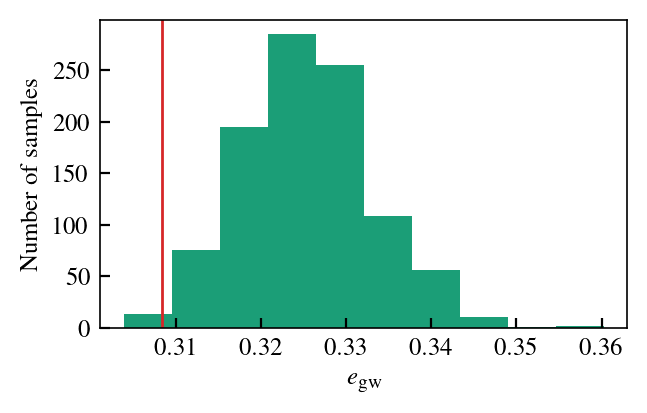

In [33]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")